# Step 1: Importing Libraries

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import glob
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling1D
from keras.layers import LSTM
from keras.callbacks import EarlyStopping

# Step 2: Reading Dataset

In [146]:
from IPython.display import display
print('Loading weather datasets...')
files = glob.glob('./datasets/ugz_ogd_meteo_d1_*.csv')
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)
display(df.head())

Loading weather datasets...


,Datum,Standort,Parameter,Intervall,Einheit,Wert,Status
0,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,RainDur,d1,min,14.85,bereinigt
1,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,T,d1,°C,4.98,bereinigt
2,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,p,d1,hPa,980.41,bereinigt
3,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,T_max_h1,d1,°C,5.56,bereinigt
4,2019-01-01T00:00+0100,Zch_Schimmelstrasse,RainDur,d1,min,21.20,bereinigt


# Step 3: Dataset Overview

In [147]:
df

,Datum,Standort,Parameter,Intervall,Einheit,Wert,Status
0,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,RainDur,d1,min,14.85,bereinigt
1,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,T,d1,°C,4.98,bereinigt
2,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,p,d1,hPa,980.41,bereinigt
3,2019-01-01T00:00+0100,Zch_Rosengartenstrasse,T_max_h1,d1,°C,5.56,bereinigt
4,2019-01-01T00:00+0100,Zch_Schimmelstrasse,RainDur,d1,min,21.20,bereinigt
...,...,...,...,...,...,...,...
107632,2018-12-31T00:00+0100,Zch_Stampfenbachstrasse,RainDur,d1,min,438.80,bereinigt
107633,2018-12-31T00:00+0100,Zch_Stampfenbachstrasse,T,d1,°C,5.19,bereinigt
107634,2018-12-31T00:00+0100,Zch_Stampfenbachstrasse,p,d1,hPa,982.43,bereinigt
107635,2018-12-31T00:00+0100,Zch_Stampfenbachstrasse,T_max_h1,d1,°C,6.30,bereinigt


__As you can see, the data set includes daily gold price information including daily Open, High and Low prices and the final price of each day (Price) along with the volume of transactions and price changes in each day.__

__Dataset Basic Information:__

In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107637 entries, 0 to 107636
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Datum      107637 non-null  object 
 1   Standort   107637 non-null  object 
 2   Parameter  107637 non-null  object 
 3   Intervall  107637 non-null  object 
 4   Einheit    107637 non-null  object 
 5   Wert       106227 non-null  float64
 6   Status     107637 non-null  object 
dtypes: float64(1), object(6)
memory usage: 5.7+ MB


__All variables are stored as object.__

# Step 4: Data Preparation

## Step 4.1: Feature Subset Selection
__Since we will not use Vol. and Change % features to predict Price, we will drop these two features:__

In [149]:
print('Pivoting data from long to wide format...')
df = df[['Datum', 'Parameter', 'Wert']]
df['Datum'] = pd.to_datetime(df['Datum'], utc=True)
df = df.pivot_table(index='Datum', columns='Parameter', values='Wert', aggfunc='mean').reset_index()
df.rename(columns={'Datum': 'Date'}, inplace=True)
df.sort_values(by='Date', ascending=True, inplace=True)
df.fillna(method='ffill', inplace=True)
df.fillna(method='bfill', inplace=True)
df.reset_index(drop=True, inplace=True)
features = df.columns.drop(['Date'])
num_features = len(features)
display(df.head())

Pivoting data from long to wide format...


Parameter,Date,RainDur,StrGlo,T,T_max_h1,p
0,1992-06-30 23:00:00+00:00,0.0,135.06,18.99,21.72,963.06
1,1992-07-01 23:00:00+00:00,0.0,149.37,18.36,21.98,965.23
2,1992-07-02 23:00:00+00:00,0.0,247.37,21.47,26.30,965.09
3,1992-07-03 23:00:00+00:00,0.0,73.66,17.53,20.55,960.75
4,1992-07-04 23:00:00+00:00,0.0,111.20,15.56,18.11,957.95


## Step 4.2: Transforming Data

__Date feature is stored as object in the data frame. To increase the speed of calculations, we convert it's data type to datetime and then sort this feature in ascending order:__

In [150]:
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by='Date', ascending=True, inplace=True)
df.reset_index(drop=True, inplace=True)

__The " , " sign is redundant in the dataset. First, we remove it from the entire dataset and then change the data type of the numerical variables to float:__

In [151]:
NumCols = df.columns.drop(['Date'])
df[NumCols] = df[NumCols].astype('float64')


__Result:__

In [152]:
df.head()

Parameter,Date,RainDur,StrGlo,T,T_max_h1,p
0,1992-06-30 23:00:00+00:00,0.0,135.06,18.99,21.72,963.06
1,1992-07-01 23:00:00+00:00,0.0,149.37,18.36,21.98,965.23
2,1992-07-02 23:00:00+00:00,0.0,247.37,21.47,26.30,965.09
3,1992-07-03 23:00:00+00:00,0.0,73.66,17.53,20.55,960.75
4,1992-07-04 23:00:00+00:00,0.0,111.20,15.56,18.11,957.95


## Step 4.3: Checking Duplicates
__There are no duplicate samples in Date feature:__

In [153]:
df.duplicated().sum()

np.int64(0)

## Step 4.4: Checking Missing Values
__There are no missing values in the dataset:__

In [154]:
df.isnull().sum().sum()

np.int64(0)

# Step 5: Visualizing Gold Price History Data

__Interactive Gold Price Chart:__

In [155]:
fig = px.line(y=df['T'], x=df.Date)
fig.update_traces(line_color='black')
fig.update_layout(xaxis_title="Date",
                  yaxis_title="Temperature (°C)",
                  title={'text': "Historical Weather Data (Temperature)", 'y':0.95, 'x':0.5, 'xanchor':'center', 'yanchor':'top'},
                  plot_bgcolor='rgba(135,206,235,0.8)')

# Step 6: Splitting Data to Training & Test Sets
__Since we cannot train on future data in time series data, we should not divide the time series data randomly. In time series splitting, testing set is always later than training set. We consider the last year for testing and everything else for training:__

In [156]:
test_size = df[df.Date.dt.year >= 2026].shape[0]
if test_size == 0:
    test_size = 365
print(f'Test size: {test_size}')

Test size: 76


__Gold Price Training and Test Sets Plot:__

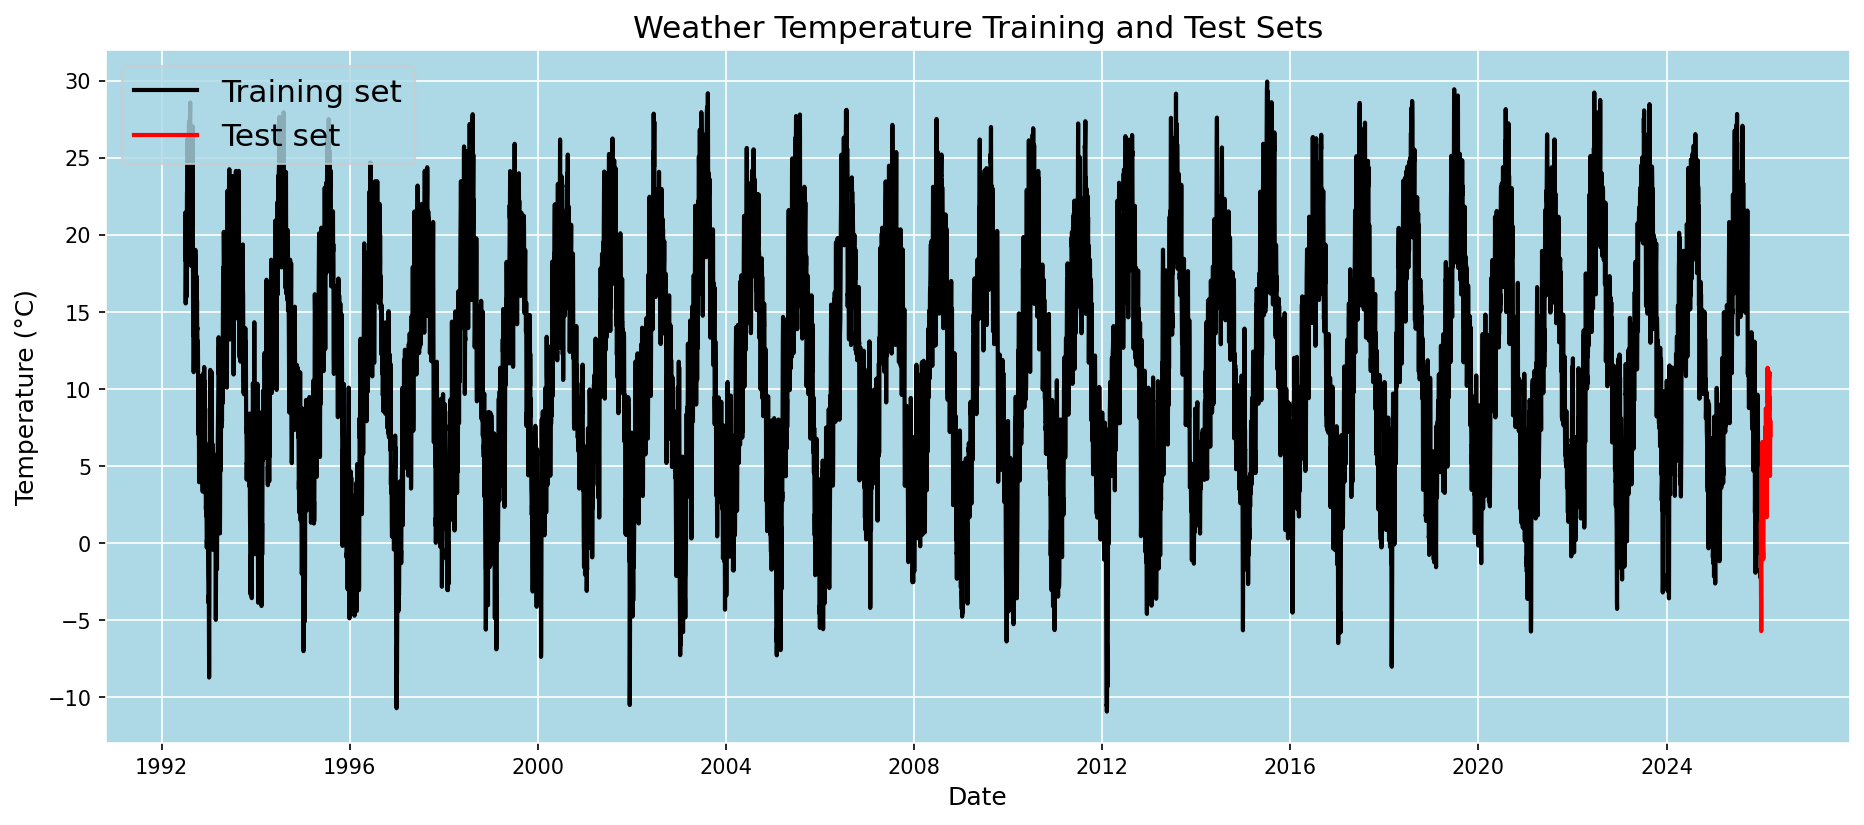

In [157]:
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'lightblue'
plt.rc('axes',edgecolor='white')
plt.plot(df.Date[:-test_size], df['T'][:-test_size], color='black', lw=2)
plt.plot(df.Date[-test_size:], df['T'][-test_size:], color='red', lw=2)
plt.title('Weather Temperature Training and Test Sets', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(['Training set', 'Test set'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

# Step 7: Data Scaling
__Since we aim to predict Price only based on its historical data, we scale Price using MinMaxScaler to avoid intensive computations:__

In [158]:
scaler = MinMaxScaler()
scaler.fit(df[features])

MinMaxScaler()

# Step 8: Restructure Data & Create Sliding Window
__The use of prior time steps to predict the next time step is called sliding window. In this way, time series data can be expressed as supervised learning. We can do this by using previous time steps as input variables and use the next time step as the output variable. The number of previous time steps is called the window width. Here we set window width to 60. Therefore, X_train and X_test will be nested lists containing lists of 60 time-stamp prices. y_train and y_test are also lists of gold prices containing the next day's gold price corresponds to each list in X_train and X_test respectively:__

In [159]:
window_size = 60

__Training Set:__

In [160]:
train_data = df[features][:-test_size]
train_data = scaler.transform(train_data)

In [161]:
X_train = []
y_train = []
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i, :])
    y_train.append(train_data[i, :])

__Test Set:__

In [162]:
test_data = df[features][-test_size-window_size:]
test_data = scaler.transform(test_data)

In [163]:
X_test = []
y_test = []
for i in range(window_size, len(test_data)):
    X_test.append(test_data[i-window_size:i, :])
    y_test.append(test_data[i, :])

# Step 9: Converting Data to Numpy Arrays

__Now X_train and X_test are nested lists (two-dimensional lists) and y_train is a one-dimensional list. We need to convert them to numpy arrays with a higher dimension, which is the data format accepted by TensorFlow when training the neural network:__

In [164]:
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

In [165]:
# Data is already 3D: (samples, window_size, features)
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)

In [166]:
print('X_train Shape: ', X_train.shape)
print('y_train Shape: ', y_train.shape)
print('X_test Shape:  ', X_test.shape)
print('y_test Shape:  ', y_test.shape)

X_train Shape:  (12138, 60, 5)
y_train Shape:  (12138, 5)
X_test Shape:   (76, 60, 5)
y_test Shape:   (76, 5)


# Step 10: Creating an LSTM Network
__We build an LSTM network, which is a type of Recurrent Neural Networks designed to solve vanishing gradient problem:__

__Model Definition:__

In [167]:
def define_model():
    input1 = Input(shape=(window_size, num_features))
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input1)
    x = MaxPooling1D(pool_size=2)(x)
    x = LSTM(64)(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    dnn_output = Dense(num_features)(x)
    model = Model(inputs=input1, outputs=[dnn_output])
    model.compile(loss='mean_squared_error', optimizer='Nadam')
    model.summary()
    return model

__Model Training:__

In [ ]:
model = define_model()
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 60, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 60, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,293 (141.77 KB)

 Trainable params: 36,293 (141.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - loss: 0.0202 - val_loss: 0.0126
Epoch 2/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0121 - val_loss: 0.0117
Epoch 3/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0107 - val_loss: 0.0104
Epoch 4/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0100 - val_loss: 0.0104
Epoch 5/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0097 - val_loss: 0.0100
Epoch 6/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0094 - val_loss: 0.0099
Epoch 7/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0092 - val_loss: 0.0101
Epoch 8/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0091 - val_loss: 0.0098
Epoch 9/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0090 - val_loss: 0.0100
Epoch 10/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - loss: 0.0089 - val_loss: 0.0099
Epoch 11/100
304/304 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0089 - val_loss: 0.0098
Epoch 12/100
304/304 ━━━━

# Step 11: Model Evaluation
__Next, we evaluate our time series forecast using MAPE (Mean Absolute Percentage Error) metric:__

In [ ]:
result = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print('Test MSE:', mse)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

MAPE = mean_absolute_percentage_error(y_test, y_pred)


print("Test Loss:", result)
print("Test MAPE:", MAPE)


# Step 12: Visualizing Results

__Returning the actual and predicted Price values to their primary scale:__

In [ ]:
y_test_true = scaler.inverse_transform(y_test)
y_test_pred = scaler.inverse_transform(y_pred)

__Investigating the closeness of the prices predicted by the model to the actual prices:__

In [ ]:
y_test_true = scaler.inverse_transform(y_test)
y_test_pred = scaler.inverse_transform(y_pred)

# Plot the first feature (T) for visibility
t_index = list(features).index('T')
plt.figure(figsize=(15, 6), dpi=150)
plt.rcParams['axes.facecolor'] = 'lightblue'
plt.rc('axes',edgecolor='white')
plt.plot(df['Date'].iloc[-test_size:], y_test_true[:, t_index], color='blue', lw=2)
plt.plot(df['Date'].iloc[-test_size:], y_test_pred[:, t_index], color='red', lw=2)
plt.title('Prediction Performance (Temperature)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(['Actual Test Data', 'Predicted Test Data'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

### Predicting Future Gold Prices
Adjust `future_days_to_predict` to generate predictions for multiple days ahead.

In [ ]:
future_days_to_predict = 10
last_window = df[features][-window_size:].values

last_window_scaled = scaler.transform(last_window)
predictions = []
current_window = last_window_scaled.copy()

for _ in range(future_days_to_predict):
    X_input = current_window.reshape(1, window_size, num_features)
    next_day_scaled = model.predict(X_input, verbose=0)
    predictions.append(next_day_scaled[0])
    current_window = np.append(current_window[1:], next_day_scaled, axis=0)

future_weather = scaler.inverse_transform(np.array(predictions))
future_df = pd.DataFrame(future_weather, columns=features)
future_df.index = [f'Day {i}' for i in range(1, future_days_to_predict + 1)]

print(f"Predicted Weather for the next {future_days_to_predict} day(s):\n")
display(future_df)